# TILDA Texture Classification

Single notebook pipeline for the MODIA ML 2026 Kaggle challenge.

Constraints used here:
- no pretrained models;
- no transfer learning;
- grayscale TIFF images;
- internal labels are `0..7`, Kaggle submission labels are `1..8`.


## 1. Setup

In [ ]:
from pathlib import Path
import random
import time

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from tqdm.auto import tqdm

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = ROOT / 'data'
OUTPUT_DIR = ROOT / 'outputs'
CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'
SUBMISSION_DIR = OUTPUT_DIR / 'submissions'
FIGURE_DIR = OUTPUT_DIR / 'figures'

for p in [CHECKPOINT_DIR, SUBMISSION_DIR, FIGURE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE


In [2]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())


2.12.0+cu126
12.6
True


## 2. Load Metadata

Expected data layout:

```text
data/train.csv
data/train/*.tif
data/test/*.tif
```

In [3]:
train_csv = DATA_DIR / 'train.csv'
train_dir = DATA_DIR / 'train'
test_dir = DATA_DIR / 'test'

df = pd.read_csv(train_csv, sep=';')
df['id'] = df['id'].astype(int)
df['label'] = df['label'].astype(int)
df['path'] = df['id'].map(lambda x: train_dir / f'{x}.tif')

print(df.head())
print(df['label'].value_counts().sort_index())
print('Train images:', len(df))
print('Test images:', len(list(test_dir.glob('*.tif'))))

   id  label                                               path
0   1      4  /home/onyxia/work/tilda-texture-classification...
1   2      6  /home/onyxia/work/tilda-texture-classification...
2   3      7  /home/onyxia/work/tilda-texture-classification...
3   4      6  /home/onyxia/work/tilda-texture-classification...
4   5      7  /home/onyxia/work/tilda-texture-classification...
label
0    300
1    300
2    262
3    300
4    300
5    299
6    300
7    300
Name: count, dtype: int64
Train images: 2361
Test images: 789


## 3. Quick Visual Check

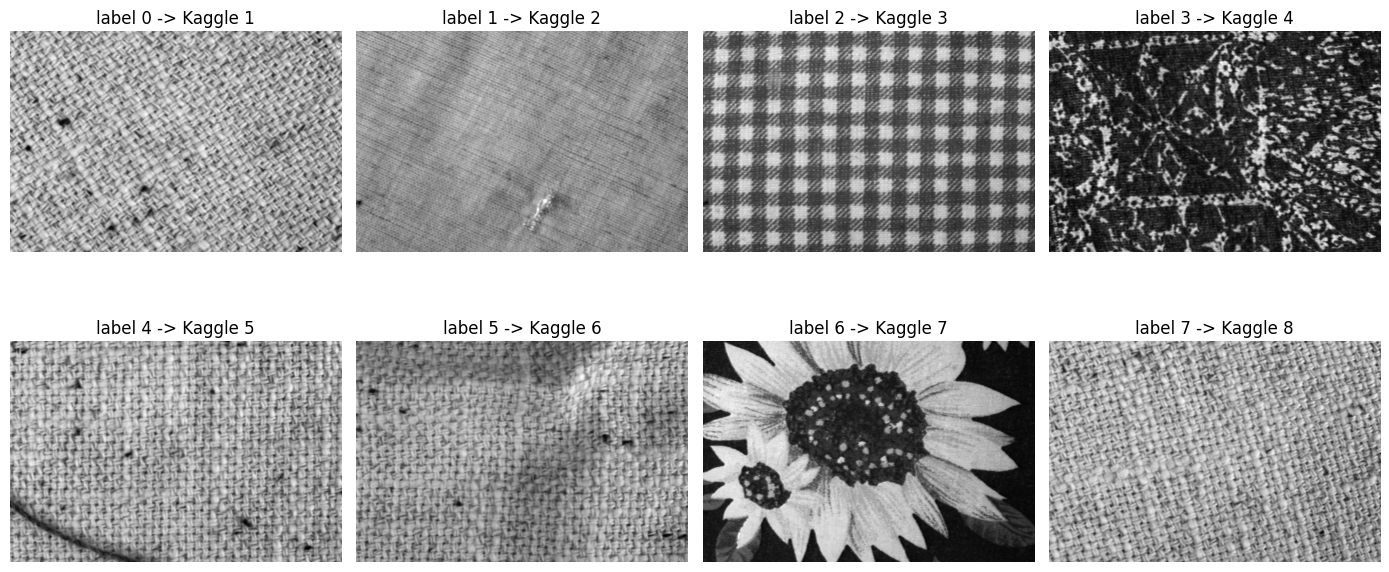

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, label in zip(axes.ravel(), sorted(df['label'].unique())):
    row = df[df['label'] == label].sample(1, random_state=SEED).iloc[0]
    img = Image.open(row['path']).convert('L')
    ax.imshow(img, cmap='gray')
    ax.set_title(f'label {label} -> Kaggle {label + 1}')
    ax.axis('off')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'samples_by_class.png', dpi=150)
plt.show()

## 4. Split + Transforms

Augmentation is applied only to the training split. Validation/test use deterministic preprocessing.

In [5]:
IMG_SIZE = (384, 576)  # height, width; preserves original 512:768 = 2:3 ratio
BATCH_SIZE = 32
NUM_WORKERS = 0        # more stable in Jupyter/Onyxia than multiprocessing workers

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df['label'],
)

# Keep augmentation moderate: classes 7 and 8 already encode illumination and affine/camera changes.
train_tfms = transforms.Compose([
    transforms.Resize((432, 648)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
    transforms.RandomErasing(p=0.10, scale=(0.01, 0.04), ratio=(0.3, 3.3)),
])

eval_tfms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

len(train_df), len(val_df)


(1888, 473)

## 5. Dataset + DataLoaders

In [6]:
class TildaDataset(Dataset):
    def __init__(self, dataframe=None, image_dir=None, ids=None, transform=None, has_labels=True):
        self.dataframe = dataframe.reset_index(drop=True) if dataframe is not None else None
        self.image_dir = Path(image_dir) if image_dir is not None else None
        self.ids = list(ids) if ids is not None else None
        self.transform = transform
        self.has_labels = has_labels

    def __len__(self):
        return len(self.dataframe) if self.has_labels else len(self.ids)

    def __getitem__(self, idx):
        if self.has_labels:
            row = self.dataframe.iloc[idx]
            image_id = int(row['id'])
            path = Path(row['path'])
            label = int(row['label'])
        else:
            image_id = int(self.ids[idx])
            path = self.image_dir / f'{image_id}.tif'
            label = -1

        image = Image.open(path).convert('L')
        if self.transform is not None:
            image = self.transform(image)

        return image, label, image_id


train_ds = TildaDataset(train_df, transform=train_tfms, has_labels=True)
val_ds = TildaDataset(val_df, transform=eval_tfms, has_labels=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

xb, yb, ids = next(iter(train_loader))
xb.shape, yb[:8]

(torch.Size([32, 1, 384, 576]), tensor([4, 4, 2, 2, 7, 0, 1, 5]))

## 6. Models From Scratch

Heavy run, still respecting the project constraint: all models are trained from scratch, without pretrained weights and without transfer learning.

Models included:

- `SmallResNet`: current best baseline.
- `ResNet18Scratch`: standard ResNet-18 style model adapted to grayscale.
- `ResNet34Scratch`: deeper standard residual model.
- `WideResNet16x8`: wider residual model, often strong on small/medium datasets.
- `WideResNet28x10`: heavier wide residual model for the A6000 run.


In [7]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout) if dropout > 0 else nn.Identity(),
        )

    def forward(self, x):
        return self.net(x)


class TextureCNN(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(1, 32, dropout=0.05),
            ConvBlock(32, 64, dropout=0.05),
            ConvBlock(64, 128, dropout=0.10),
            ConvBlock(128, 256, dropout=0.10),
            ConvBlock(256, 384, dropout=0.15),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.35),
            nn.Linear(384, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, dropout=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
        self.shortcut = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out = self.relu(out + identity)
        return out


class SmallResNet(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=2, padding=2, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.layer1 = nn.Sequential(ResidualBlock(32, 32), ResidualBlock(32, 32, dropout=0.05))
        self.layer2 = nn.Sequential(ResidualBlock(32, 64, stride=2), ResidualBlock(64, 64, dropout=0.05))
        self.layer3 = nn.Sequential(ResidualBlock(64, 128, stride=2), ResidualBlock(128, 128, dropout=0.10))
        self.layer4 = nn.Sequential(ResidualBlock(128, 256, stride=2), ResidualBlock(256, 256, dropout=0.15))
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.35),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        return self.head(x)


class ResNetBasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, dropout=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
        self.downsample = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        identity = self.downsample(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        return self.relu(out + identity)


class ResNetScratch(nn.Module):
    def __init__(self, layers, num_classes=8, base_width=64, dropout=0.10):
        super().__init__()
        self.in_channels = base_width
        self.stem = nn.Sequential(
            nn.Conv2d(1, base_width, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(base_width),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )
        self.layer1 = self._make_layer(base_width, layers[0], stride=1, dropout=dropout)
        self.layer2 = self._make_layer(base_width * 2, layers[1], stride=2, dropout=dropout)
        self.layer3 = self._make_layer(base_width * 4, layers[2], stride=2, dropout=dropout)
        self.layer4 = self._make_layer(base_width * 8, layers[3], stride=2, dropout=dropout)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.35),
            nn.Linear(base_width * 8, num_classes),
        )

    def _make_layer(self, out_channels, blocks, stride, dropout):
        layers = [ResNetBasicBlock(self.in_channels, out_channels, stride=stride, dropout=dropout)]
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(ResNetBasicBlock(self.in_channels, out_channels, stride=1, dropout=dropout))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        return self.head(x)


class ResNet18Scratch(ResNetScratch):
    def __init__(self, num_classes=8):
        super().__init__([2, 2, 2, 2], num_classes=num_classes, base_width=64, dropout=0.08)


class ResNet34Scratch(ResNetScratch):
    def __init__(self, num_classes=8):
        super().__init__([3, 4, 6, 3], num_classes=num_classes, base_width=64, dropout=0.08)


class WideBasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, dropout=0.0):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu2 = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.shortcut = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False)

    def forward(self, x):
        out = self.relu1(self.bn1(x))
        shortcut = self.shortcut(out if not isinstance(self.shortcut, nn.Identity) else x)
        out = self.conv1(out)
        out = self.relu2(self.bn2(out))
        out = self.dropout(out)
        out = self.conv2(out)
        return out + shortcut


class WideResNet(nn.Module):
    def __init__(self, depth=28, widen_factor=10, dropout=0.20, num_classes=8):
        super().__init__()
        assert (depth - 4) % 6 == 0, 'WideResNet depth should be 6n + 4'
        n = (depth - 4) // 6
        widths = [32, 32 * widen_factor, 64 * widen_factor, 128 * widen_factor]
        self.conv1 = nn.Conv2d(1, widths[0], kernel_size=3, padding=1, bias=False)
        self.block1 = self._make_group(widths[0], widths[1], n, stride=2, dropout=dropout)
        self.block2 = self._make_group(widths[1], widths[2], n, stride=2, dropout=dropout)
        self.block3 = self._make_group(widths[2], widths[3], n, stride=2, dropout=dropout)
        self.bn = nn.BatchNorm2d(widths[3])
        self.relu = nn.ReLU(inplace=True)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.35),
            nn.Linear(widths[3], num_classes),
        )

    def _make_group(self, in_channels, out_channels, blocks, stride, dropout):
        layers = [WideBasicBlock(in_channels, out_channels, stride=stride, dropout=dropout)]
        for _ in range(1, blocks):
            layers.append(WideBasicBlock(out_channels, out_channels, stride=1, dropout=dropout))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.relu(self.bn(x))
        return self.head(x)


class WideResNet16x8(WideResNet):
    def __init__(self, num_classes=8):
        super().__init__(depth=16, widen_factor=8, dropout=0.20, num_classes=num_classes)


class WideResNet28x10(WideResNet):
    def __init__(self, num_classes=8):
        super().__init__(depth=28, widen_factor=10, dropout=0.25, num_classes=num_classes)


MODEL_REGISTRY = {
    'small_resnet': SmallResNet,
    'resnet18_scratch': ResNet18Scratch,
    'resnet34_scratch': ResNet34Scratch,
    'wide_resnet16x8': WideResNet16x8,
    'wide_resnet28x10': WideResNet28x10,
}


def build_model(model_name, num_classes=8):
    if model_name not in MODEL_REGISTRY:
        raise ValueError(f'Unknown model: {model_name}')
    return MODEL_REGISTRY[model_name](num_classes=num_classes)


for name in MODEL_REGISTRY:
    model = build_model(name).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters())
    print(f'{name:18s}: {n_params:,} parameters')
    del model
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()


small_resnet      : 2,797,032 parameters
resnet18_scratch  : 11,174,344 parameters
resnet34_scratch  : 21,282,504 parameters
wide_resnet16x8   : 43,817,320 parameters
wide_resnet28x10  : 145,864,040 parameters


## 7. Training Loop

In [8]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.set_grad_enabled(is_train):
        for images, labels, _ in tqdm(loader, leave=False):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            all_preds.extend(logits.argmax(dim=1).detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc


def train_model(model, train_loader, val_loader, model_name, epochs=160, lr=0.03, weight_decay=5e-4, patience=40):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9,
        weight_decay=weight_decay,
        nesterov=True,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

    history = []
    best_acc = -1.0
    best_epoch = 0
    best_path = CHECKPOINT_DIR / f'best_{model_name}.pt'
    start = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)
        scheduler.step()

        row = {
            'model': model_name,
            'epoch': epoch,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'lr': scheduler.get_last_lr()[0],
        }
        history.append(row)

        if val_acc > best_acc:
            best_acc = val_acc
            best_epoch = epoch
            torch.save({
                'model_name': model_name,
                'model_state_dict': model.state_dict(),
                'history': history,
                'best_acc': best_acc,
                'best_epoch': best_epoch,
                'img_size': IMG_SIZE,
                'optimizer': 'SGD(momentum=0.9, nesterov=True)',
            }, best_path)

        print(
            f"{model_name} | Epoch {epoch:03d} | "
            f"train {train_acc:.4f}/{train_loss:.4f} | "
            f"val {val_acc:.4f}/{val_loss:.4f} | "
            f"best {best_acc:.4f} @ {best_epoch}"
        )

        if epoch - best_epoch >= patience:
            print(f'{model_name}: early stopping after {patience} epochs without validation improvement.')
            break

    elapsed_min = (time.time() - start) / 60
    print(f'{model_name}: training time {elapsed_min:.1f} min, best validation accuracy {best_acc:.4f}')
    return pd.DataFrame(history), best_path, best_acc, best_epoch, elapsed_min


## 8. Official Scratch Run: 5-Fold Ensemble

This section is compliant with the project constraints:

- no pretrained weights;
- no transfer learning;
- mini-batch SGD with momentum;
- labels stay `0..7`, exactly as in `train.csv`;
- ratio-preserving preprocessing: `384x576`.

It trains several from-scratch models sequentially and generates one submission per model plus ensemble submissions.


In [ ]:
N_SPLITS = 5

OFFICIAL_EXPERIMENTS = [
    {'name': 'resnet18_scratch', 'epochs': 180, 'lr': 0.030, 'weight_decay': 5e-4, 'patience': 45},
    {'name': 'small_resnet', 'epochs': 180, 'lr': 0.030, 'weight_decay': 5e-4, 'patience': 45},
]

# Add this only if you have enough time; previous ResNet34 was weaker than ResNet18.
RUN_RESNET34_TOO = False
if RUN_RESNET34_TOO:
    OFFICIAL_EXPERIMENTS.append(
        {'name': 'resnet34_scratch', 'epochs': 200, 'lr': 0.025, 'weight_decay': 5e-4, 'patience': 50}
    )

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
test_ids = sorted([int(p.stem) for p in test_dir.glob('*.tif')])
test_ds = TildaDataset(image_dir=test_dir, ids=test_ids, transform=eval_tfms, has_labels=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

all_fold_results = []
all_histories = {}
all_model_test_probs = {}
ids_reference = None


def make_loaders(train_part, val_part):
    train_ds = TildaDataset(train_part, transform=train_tfms, has_labels=True)
    val_ds = TildaDataset(val_part, transform=eval_tfms, has_labels=True)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    return train_loader, val_loader


def predict_proba(model, loader, use_tta=True):
    model.eval()
    all_probs = []
    all_ids = []

    with torch.no_grad():
        for images, _, image_ids in tqdm(loader, leave=False):
            images = images.to(DEVICE, non_blocking=True)
            logits_list = [model(images)]

            if use_tta:
                logits_list.append(model(torch.flip(images, dims=[-1])))       # horizontal flip
                logits_list.append(model(torch.flip(images, dims=[-2])))       # vertical flip
                logits_list.append(model(torch.flip(images, dims=[-2, -1])))   # both flips

            probs = torch.stack([torch.softmax(logits, dim=1) for logits in logits_list]).mean(dim=0)
            all_probs.append(probs.cpu())
            all_ids.extend(image_ids.numpy().tolist())

    return torch.cat(all_probs, dim=0).numpy(), np.array(all_ids)


for exp in OFFICIAL_EXPERIMENTS:
    model_name = exp['name']
    model_fold_probs = []
    print('\n' + '#' * 90)
    print(f'OFFICIAL 5-FOLD TRAINING: {model_name}')
    print('#' * 90)

    for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['label']), start=1):
        fold_name = f'{model_name}_ratio_fold{fold}'
        print('\n' + '=' * 80)
        print(f'Training {fold_name}')
        print('=' * 80)

        fold_train_df = df.iloc[train_idx].reset_index(drop=True)
        fold_val_df = df.iloc[val_idx].reset_index(drop=True)
        fold_train_loader, fold_val_loader = make_loaders(fold_train_df, fold_val_df)

        model = build_model(model_name).to(DEVICE)
        history, best_path, best_acc, best_epoch, elapsed_min = train_model(
            model,
            fold_train_loader,
            fold_val_loader,
            model_name=fold_name,
            epochs=exp['epochs'],
            lr=exp['lr'],
            weight_decay=exp['weight_decay'],
            patience=exp['patience'],
        )

        history_path = OUTPUT_DIR / f'history_{fold_name}.csv'
        history.to_csv(history_path, index=False)
        all_histories[fold_name] = history

        # Reload best checkpoint before predicting test.
        checkpoint = torch.load(best_path, map_location=DEVICE)
        model.load_state_dict(checkpoint['model_state_dict'])
        probs, ids = predict_proba(model, test_loader, use_tta=True)

        if ids_reference is None:
            ids_reference = ids
        else:
            assert np.array_equal(ids_reference, ids)

        model_fold_probs.append(probs)
        fold_preds = probs.argmax(axis=1)
        fold_submission = pd.DataFrame({'id': ids, 'label': fold_preds}).sort_values('id')
        fold_submission_path = SUBMISSION_DIR / f'submission_{fold_name}.csv'
        fold_submission.to_csv(fold_submission_path, index=False)

        all_fold_results.append({
            'model': model_name,
            'fold': fold,
            'fold_name': fold_name,
            'best_val_acc': best_acc,
            'best_epoch': best_epoch,
            'training_time_min': elapsed_min,
            'checkpoint': str(best_path),
            'history': str(history_path),
            'submission': str(fold_submission_path),
            'img_size': str(IMG_SIZE),
            'submission_labels': '0..7',
        })

        del model
        if DEVICE.type == 'cuda':
            torch.cuda.empty_cache()

    # Model-level 5-fold ensemble.
    model_probs = np.mean(model_fold_probs, axis=0)
    all_model_test_probs[model_name] = model_probs
    model_preds = model_probs.argmax(axis=1)
    model_submission = pd.DataFrame({'id': ids_reference, 'label': model_preds}).sort_values('id')
    model_submission_path = SUBMISSION_DIR / f'submission_{model_name}_5fold_ratio_tta_labels0.csv'
    model_submission.to_csv(model_submission_path, index=False)
    print('Saved model 5-fold ensemble:', model_submission_path)
    print(model_submission['label'].value_counts().sort_index())

fold_results_df = pd.DataFrame(all_fold_results)
fold_results_path = OUTPUT_DIR / 'model_results_5fold_ratio.csv'
fold_results_df.to_csv(fold_results_path, index=False)
fold_results_df.sort_values(['model', 'fold'])


## 9. Validation Diagnostics


In [ ]:
# Fold summary table.
display(fold_results_df.groupby('model')['best_val_acc'].agg(['mean', 'std', 'min', 'max']).sort_values('mean', ascending=False))

# Plot validation curves for all folds.
fig, ax = plt.subplots(figsize=(10, 5))
for fold_name, history in all_histories.items():
    ax.plot(history['epoch'], history['val_acc'], label=fold_name, alpha=0.75)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation accuracy')
ax.grid(True)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'all_validation_accuracy_5fold_ratio.png', dpi=150)
plt.show()


In [ ]:
# Confusion matrix for the best fold by local validation.
best_row = fold_results_df.sort_values('best_val_acc', ascending=False).iloc[0]
best_model_name = best_row['model']
best_fold_name = best_row['fold_name']
best_checkpoint = Path(best_row['checkpoint'])
print('Best fold:', best_fold_name)
print('Best checkpoint:', best_checkpoint)

# Rebuild that fold validation loader.
fold_number = int(best_row['fold'])
fold_pairs = list(skf.split(df, df['label']))
_, val_idx = fold_pairs[fold_number - 1]
best_val_df = df.iloc[val_idx].reset_index(drop=True)
best_val_ds = TildaDataset(best_val_df, transform=eval_tfms, has_labels=True)
best_val_loader = DataLoader(best_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

model = build_model(best_model_name).to(DEVICE)
checkpoint = torch.load(best_checkpoint, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

val_preds, val_labels = [], []
with torch.no_grad():
    for images, labels, _ in best_val_loader:
        images = images.to(DEVICE, non_blocking=True)
        logits = model(images)
        val_preds.extend(logits.argmax(dim=1).cpu().numpy())
        val_labels.extend(labels.numpy())

print('Best fold validation accuracy:', accuracy_score(val_labels, val_preds))
cm = confusion_matrix(val_labels, val_preds, labels=list(range(8)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[str(i) for i in range(8)])
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title(f'Validation confusion matrix: {best_fold_name}, labels 0..7')
plt.savefig(FIGURE_DIR / f'confusion_matrix_{best_fold_name}.png', dpi=150)
plt.show()

del model
if DEVICE.type == 'cuda':
    torch.cuda.empty_cache()


## 10. Create Official 5-Fold Submissions

All files in this section use labels `0..7`, matching `train.csv` and the observed Kaggle scoring behavior.


In [ ]:
# One submission per model was already written during training.
# Now create a global ensemble across all official model families.

available_model_names = list(all_model_test_probs.keys())
print('Available official models:', available_model_names)

if available_model_names:
    official_probs = np.mean([all_model_test_probs[name] for name in available_model_names], axis=0)
    official_preds = official_probs.argmax(axis=1)
    official_submission = pd.DataFrame({'id': ids_reference, 'label': official_preds}).sort_values('id')
    official_submission_path = SUBMISSION_DIR / 'submission_official_5fold_all_scratch_ratio_tta_labels0.csv'
    official_submission.to_csv(official_submission_path, index=False)
    print('Saved official scratch ensemble:', official_submission_path)
    print(official_submission['label'].value_counts().sort_index())
    display(official_submission.head())


## 11. Experimental Pretrained ConvNeXt-Tiny

This section is **not compliant with the course constraint** if pretrained models are forbidden. Use it only as a private comparison experiment. Do not use it in the official report/submission unless the instructor explicitly allows pretrained weights.


In [ ]:
RUN_PRETRAINED_CONVNEXT_EXPERIMENT = False  # Private comparison only; not official and no Kaggle CSV is generated.

if RUN_PRETRAINED_CONVNEXT_EXPERIMENT:
    PRETRAINED_IMG_SIZE = (384, 576)
    PRETRAINED_BATCH_SIZE = 16

    weights = models.ConvNeXt_Tiny_Weights.DEFAULT
    imagenet_mean = weights.transforms().mean
    imagenet_std = weights.transforms().std

    pretrained_train_tfms = transforms.Compose([
        transforms.Resize((432, 648)),
        transforms.RandomCrop(PRETRAINED_IMG_SIZE),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=5),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
        transforms.RandomErasing(p=0.10, scale=(0.01, 0.04), ratio=(0.3, 3.3)),
    ])

    pretrained_eval_tfms = transforms.Compose([
        transforms.Resize(PRETRAINED_IMG_SIZE),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ])

    pretrained_train_df, pretrained_val_df = train_test_split(
        df,
        test_size=0.2,
        random_state=SEED,
        stratify=df['label'],
    )

    pretrained_train_ds = TildaDataset(pretrained_train_df, transform=pretrained_train_tfms, has_labels=True)
    pretrained_val_ds = TildaDataset(pretrained_val_df, transform=pretrained_eval_tfms, has_labels=True)
    pretrained_train_loader = DataLoader(pretrained_train_ds, batch_size=PRETRAINED_BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    pretrained_val_loader = DataLoader(pretrained_val_ds, batch_size=PRETRAINED_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    convnext = models.convnext_tiny(weights=weights)
    convnext.classifier[-1] = nn.Linear(convnext.classifier[-1].in_features, 8)
    convnext = convnext.to(DEVICE)

    def train_pretrained_model(model, train_loader, val_loader, epochs=40, lr=1e-4, weight_decay=1e-4, patience=10):
        criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
        best_acc = -1.0
        best_epoch = 0
        history = []
        best_path = CHECKPOINT_DIR / 'experimental_best_convnext_tiny_pretrained.pt'

        for epoch in range(1, epochs + 1):
            train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
            val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)
            scheduler.step()
            history.append({'epoch': epoch, 'train_loss': train_loss, 'train_acc': train_acc, 'val_loss': val_loss, 'val_acc': val_acc})
            if val_acc > best_acc:
                best_acc = val_acc
                best_epoch = epoch
                torch.save({'model_state_dict': model.state_dict(), 'best_acc': best_acc, 'best_epoch': best_epoch}, best_path)
            print(f'convnext_tiny_pretrained | Epoch {epoch:03d} | train {train_acc:.4f}/{train_loss:.4f} | val {val_acc:.4f}/{val_loss:.4f} | best {best_acc:.4f} @ {best_epoch}')
            if epoch - best_epoch >= patience:
                break

        history_df = pd.DataFrame(history)
        history_df.to_csv(OUTPUT_DIR / 'experimental_history_convnext_tiny_pretrained.csv', index=False)
        return best_path, history_df, best_acc

    convnext_path, convnext_history, convnext_best_acc = train_pretrained_model(convnext, pretrained_train_loader, pretrained_val_loader)
    print('Private pretrained comparison finished.')
    print('Best validation accuracy:', convnext_best_acc)
    print('Checkpoint:', convnext_path)
    print('No Kaggle submission CSV is generated because pretrained weights are not allowed for the official project.')
else:
    print('Pretrained ConvNeXt experiment skipped. Set RUN_PRETRAINED_CONVNEXT_EXPERIMENT = True for private validation comparison only.')
